# Numerical Simulation Laboratory (NSL) 
## Numerical exercises 10

### Exercise 10.1

Choose **ONLY ONE** of the two following possibilities:

1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

2. Starting from your Genetic Algorithm code implement a **Parallel Tempering algorithm** (Simulated Annealing with many temperatures). Parallelize with MPI libraries your algorithm in order to solve the TSP where each computing node, up to 11, is characterized by a different temperature or a limited set of temperatures (if you need more than 11 temperatures). Use your genetic operators (except crossover) as trial moves for the Metropolis algorithm and **add a trial move that proposes an exchange of paths among adjacent temperatures (nodes)** (see lecture 8 for the acceptance formula). The candidate solution of the TSP will appear on the node with the lowest temperature.

### Exercise 10.2

Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with **independent GA searches** ?

If your choice in Exercise 10.1 is option 2, by using a number of temperatures equal to the number of individuals in your **non-parallel Genetic Algorithm code**, do you "improve" with respect to it?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection

### Implementation

In questo esercizio abbiamo esteso il GA sviluppato nell'esercitazione precedente per risolvere il TSP su 110 “capoluoghi di provincia” d’Italia, parallelizzando il calcolo con MPI. L’idea è di eseguire fino a 11 istanze indipendenti del GA (i cosiddetti “Continents”), che ogni $N_{mig}$ generazioni si scambiano fra loro i migliori individui.

#### Modifiche alla classe Individual

1. **Generazione sicura di interi**  
   Aggiunta della funzione `RandInt(Random &rnd, int min, int max_included)`  
   • produce numeri nell’intervallo [min, max_included],  
   • evita errori di indice fuori limite dovuti a `Rannyu()`.

2. **Swap con controlli**  
   La firma `Swap(int i, int j, const string &caller)` verifica che `i,j ∈ [0,N−1]` e, in caso di errore, stampa un messaggio diagnostico con il nome del chiamante.

3. **Mutazioni protette**  
   Tutti gli operatori genetici (`PairPermutation`, `Shift`, `AdiacentPermutation`, `Inversion`) ora usano `RandInt` per garantire che gli indici di blocco e spostamento restino sempre validi. Viene eseguito `Check()` dopo ogni operazione per assicurarsi che:
   - la città 0 rimanga in posizione fissa,
   - la permutazione sia valida (nessuna città duplicata).


#### Modifiche alla classe Population

1. **Nuovo metodo InitializeByFile:**

```cpp
void InitializeByFile(Random &rnd,
                      const string &filename,
                      int num_of_cities,
                      int npop,
                      int ngen,
                      double mut_prob,
                      double p_exp,
                      int rank);
```
- Legge da file (cap_prov_ita.dat) le coordinate (lat/long) delle 110 città.
- Costruisce la matrice delle distanze come in precedenza.
- Inizializza una popolazione di npop individui con path casuali.
- Apro un file di log Italy_loss_rank_<rank>.dat per ogni processo MPI.

2. **Migrazione tra continents:**
- Bool migration per abilitare/disabilitare lo scambio di migranti.
- BestFitness() restituisce la fitness del miglior individuo.
- GetBestPath() e EvaluateImmigrant(const arma::uvec &path):
    - GetBestPath() estrae il path migliore come uvec.
    - EvaluateImmigrant() sostituisce il peggior individuo con il nuovo arrivato e riordina la popolazione.

#### Programma principale con MPI

1. **Inizializzazione MPI:**
```cpp
MPI_Init(&argc,&argv);
MPI_Comm_rank(MPI_COMM_WORLD,&rank);
MPI_Comm_size(MPI_COMM_WORLD,&size);
MPI_Barrier(MPI_COMM_WORLD);
double t0 = MPI_Wtime();
```

2. **Parametri GA:**
```cpp
int num_of_cities = 110;
int npop          = 700;
int ngen          = 4000;
int nmig          = 50;    // ogni 50 generazioni
double mut_prob   = 0.1;
double p_exp      = 3.0;
bool migration    = false; // switch migrazione
```

3. **Costruzione Popolazione:**
```cpp
Population population;
population.InitializeByFile(rnd,
                            "cap_prov_ita.dat",
                            num_of_cities,
                            npop, ngen,
                            mut_prob, p_exp,
                            rank);
```

4. **Loop Evolutivo con Migrazione**
```cpp
for(int gen=0; gen<ngen; gen++) {
  population.NewGeneration();

  if(migration && gen>0 && gen%nmig==0) {
    // 1) Rank 0 crea un vettore `destinations[0..size-1]`
    //    con uno shuffle casuale di 0..size-1
    // 2) MPI_Bcast(destinations)
    // 3) Ogni rank invia il proprio best_path a destinazione
    //    e riceve da chi lo deve inviare (MPI_Sendrecv)
    // 4) population.EvaluateImmigrant(received_path);
  }
}
```

5. **Riduzione dei Risultati:**
```cpp
double local_best  = population.BestFitness();
double global_best;
MPI_Reduce(&local_best,&global_best,1,MPI_DOUBLE,
           MPI_MIN,0,MPI_COMM_WORLD);
double elapsed = MPI_Wtime() - t0, max_elapsed;
MPI_Reduce(&elapsed,&max_elapsed,1,MPI_DOUBLE,
           MPI_MAX,0,MPI_COMM_WORLD);

if(rank==0) {
  cout << "Global best = " << global_best << "\n"
       << "Elapsed time = " << max_elapsed << " s\n";
}
```

#### Produzione Risultati e Confronti
- Esecuzione senza migrazione (migration=false): ogni continente evolve in completa indipendenza.
- Esecuzione con migrazione (migration=true): ogni 50 generazioni i continenti condividono il proprio migliore percorso, migliorando la diversità genetica e la convergenza complessiva.



Best path length (without migrations): 67.93
Best path length (with migrations): 69.63


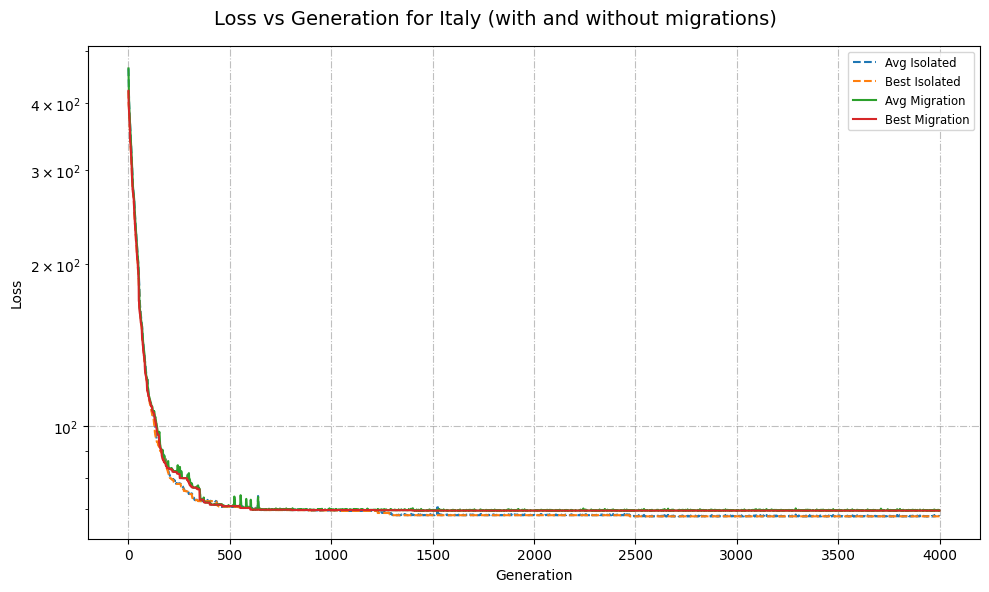

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

path_iso = "no_migration/Italy_loss_rank_0.dat"
if os.path.exists(path_iso):
    d = np.loadtxt(path_iso)
    plt.plot(d[:, 0], d[:, 2], color='#1f77b4', linestyle='--', linewidth=1.5, label='Avg Isolated')
    plt.plot(d[:, 0], d[:, 1], color='#ff7f0e', linestyle='--', linewidth=1.5, label='Best Isolated')
    print(f"Best path length (without migrations): {d[-1, 2]:.2f}")
else:
    print(f"File not found: {path_iso}")

path_mig = "migration/Italy_loss_rank_0.dat"
if os.path.exists(path_mig):
    d = np.loadtxt(path_mig)
    plt.plot(d[:, 0], d[:, 2], color='#2ca02c', linestyle='-', linewidth=1.5, label='Avg Migration')
    plt.plot(d[:, 0], d[:, 1], color='#d62728', linestyle='-', linewidth=1.5, label='Best Migration')
    print(f"Best path length (with migrations): {d[-1, 2]:.2f}")
else:
    print(f"File not found: {path_mig}")

plt.xlabel("Generation")
plt.ylabel("Loss")
if np.all(d[:, 1] > 0) and np.all(d[:, 2] > 0):
    plt.yscale('log')
else:
    print("Warning: Non-positive values in data. Using linear scale.")

plt.grid(True, linestyle='-.', alpha=0.5, color='gray') 
plt.legend(loc='best', fontsize='small', frameon=True)

plt.suptitle("Loss vs Generation for Italy (with and without migrations)", fontsize=14)
plt.tight_layout()
plt.show()

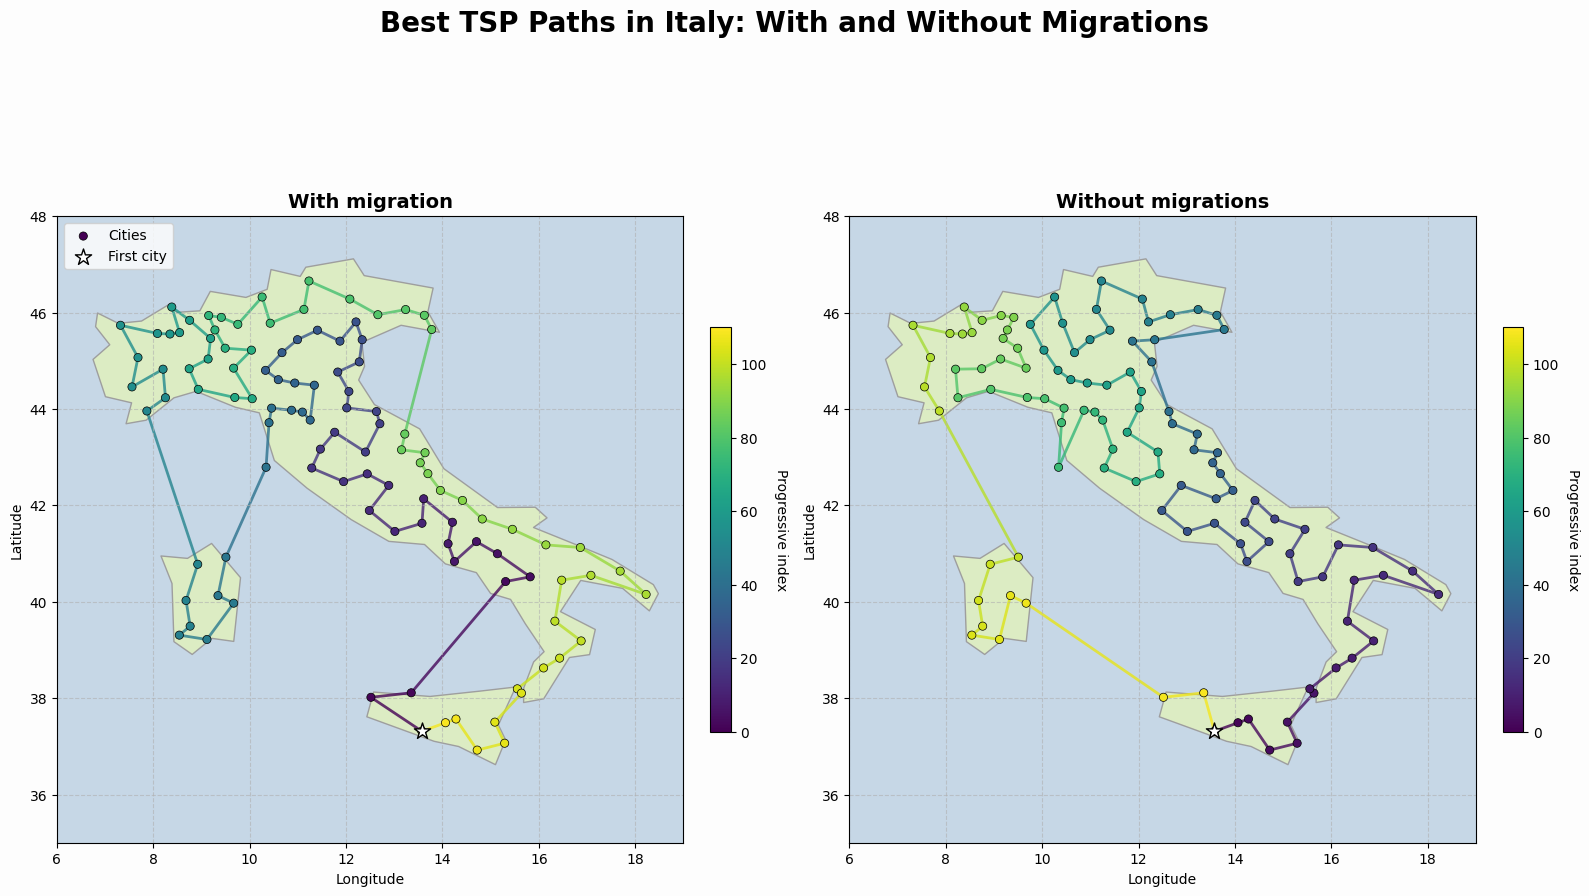

In [4]:
def plot_tsp_italy_comparison(file_migration, file_isolated):

    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    try:
        world = gpd.read_file(url)
        italy = world[world['NAME'] == "Italy"]
    except Exception as e:
        print(f"Errore nel caricamento della mappa: {e}")
        return

    files = [file_migration, file_isolated]
    titles = ["With migration", "Without migrations"]
    fig, axes = plt.subplots(1, 2, figsize=(16, 10), facecolor='#fdfdfd')
    
    for i, (ax, filename) in enumerate(zip(axes, files)):
        ax.set_facecolor("#c6d7e6") 
        italy.plot(ax=ax, color="#dcecc3", edgecolor='#9e9e9e', linewidth=1, zorder=0)

        if os.path.exists(filename):
            data = np.loadtxt(filename)
            lon = data[:, 0]
            lat = data[:, 1]
            num_points = len(lon)

            for j in range(num_points - 1):
                color = plt.cm.viridis(j / num_points)
                ax.plot(lon[j:j+2], lat[j:j+2], color=color, lw=2, zorder=1, alpha=0.8)

            sc = ax.scatter(lon, lat, 
                            c=np.arange(num_points), 
                            cmap='viridis', 
                            s=35, 
                            edgecolors='black', 
                            linewidths=0.5, 
                            zorder=2, 
                            label='Cities')

            ax.scatter(lon[0], lat[0], c='white', s=150, edgecolors='black', 
                        marker='*', zorder=3, label='First city')
            
            cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
            cbar.set_label('Progressive index', rotation=270, labelpad=15)
        else:
            ax.text(0.5, 0.5, f"File not found:\n{filename}", 
                    ha='center', va='center', transform=ax.transAxes)

        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_xlim([6, 19])
        ax.set_ylim([35, 48])
        ax.set_aspect('equal')
        ax.grid(True, linestyle='--', alpha=0.6)
        if i == 0:
            ax.legend(loc='upper left')

    plt.tight_layout()
    plt.suptitle("Best TSP Paths in Italy: With and Without Migrations", fontsize=20, fontweight='bold', y=1.02)
    #plt.savefig("tsp_comparison_italy.png")
    plt.show()

if __name__ == "__main__":
    plot_tsp_italy_comparison(
        "migration/italy_best_path_rank_0.dat", 
        "no_migration/italy_best_path_rank_0.dat"
    )